<a href="https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [8]:
# ============================================================
# CAPSTONE — SECTION 1: QUESTION
# Lane 2 — Refresh / Content Opportunity Scoring
# ============================================================

from pathlib import Path
import os
import sys
import subprocess
import pandas as pd

# ------------------------------------------------------------
# 1. Set up the repository
# ------------------------------------------------------------

REPO_URL = "https://github.com/saisathwik2703/flyrank-ml-internship-starter.git"
REPO_DIR = Path("/content/flyrank-ml-internship-starter")

if not REPO_DIR.exists():
    print("Cloning the FlyRank repository...")
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True
    )
else:
    print("Repository already exists.")

os.chdir(REPO_DIR)

print("Working directory:")
print(Path.cwd())

# ------------------------------------------------------------
# 2. Install the repository requirements
# ------------------------------------------------------------

print("\nInstalling required packages...")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True
)

print("Requirements installed.")

# ------------------------------------------------------------
# 3. Define the research question
# ------------------------------------------------------------

research_question = (
    "Which existing content items should be reviewed first for "
    "refresh, expansion, protection, pruning, or monitoring?"
)

decision_supported = (
    "The output supports a reviewer in deciding which content items "
    "to inspect first when planning content refresh work."
)

print("\nRESEARCH QUESTION")
print("-----------------")
print(research_question)

print("\nDECISION SUPPORTED")
print("------------------")
print(decision_supported)

# ------------------------------------------------------------
# 4. Explain the ML task
# ------------------------------------------------------------

task_type = "Classification + ranking"

target_definition = (
    "The classification target is is_declining_label, which is 1 when "
    "trend_direction is 'down' and 0 otherwise."
)

output_definition = (
    "The classification probability is then combined with a transparent "
    "baseline score to produce a ranked refresh-review queue."
)

print("\nML TASK")
print("-------")
print(task_type)

print("\nTARGET")
print("------")
print(target_definition)

print("\nOUTPUT")
print("------")
print(output_definition)

# ------------------------------------------------------------
# 5. Explain why ML is useful
# ------------------------------------------------------------

why_ml = (
    "A fixed rule can highlight obvious cases such as stale pages or "
    "low CTR, but it does not combine several signals into one learned "
    "decline-risk estimate. The ML model provides a probability that can "
    "be used with the transparent baseline to prioritize review."
)

print("\nWHY ML INSTEAD OF ONLY A FIXED RULE?")
print("------------------------------------")
print(why_ml)

# ------------------------------------------------------------
# 6. Load the starter data
# ------------------------------------------------------------

DATA_PATH = REPO_DIR / "data" / "raw" / "content_refresh_anonymized.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Starter dataset was not found at: {DATA_PATH}"
    )

raw_df = pd.read_csv(DATA_PATH)

print("\nDATA CHECK")
print("----------")
print("Dataset path:", DATA_PATH)
print("Rows:", f"{len(raw_df):,}")
print("Columns:", len(raw_df.columns))

# ------------------------------------------------------------
# 7. Show the unit of analysis
# ------------------------------------------------------------

print("\nUNIT OF ANALYSIS")
print("----------------")
print("One row represents one pseudonymized content item.")

# ------------------------------------------------------------
# 8. Show the target distribution
# ------------------------------------------------------------

if "trend_direction" in raw_df.columns:
    target_counts = (
        raw_df["trend_direction"]
        .astype(str)
        .str.lower()
        .value_counts(dropna=False)
    )

    print("\nOBSERVED TREND-DIRECTION COUNTS")
    print("-------------------------------")
    print(target_counts)

    print("\nPotential declining-label rate:")
    declining_rate = (
        raw_df["trend_direction"]
        .astype(str)
        .str.lower()
        .eq("down")
        .mean()
    )

    print(f"{declining_rate:.3%}")

# ------------------------------------------------------------
# 9. Public-safe check
# ------------------------------------------------------------

forbidden_public_fields = [
    "client_name",
    "domain",
    "url",
    "title",
    "query",
    "keyword"
]

present_forbidden = [
    column
    for column in forbidden_public_fields
    if column in raw_df.columns
]

print("\nPUBLIC-SAFE CHECK")
print("-----------------")

if present_forbidden:
    print("Review these fields before publishing:", present_forbidden)
else:
    print("No client names, URLs, private queries, titles, or keywords "
          "were found in the dataset columns.")

print("\nSection 1 complete.")

Repository already exists.
Working directory:
/content/flyrank-ml-internship-starter

Installing required packages...
Requirements installed.

RESEARCH QUESTION
-----------------
Which existing content items should be reviewed first for refresh, expansion, protection, pruning, or monitoring?

DECISION SUPPORTED
------------------
The output supports a reviewer in deciding which content items to inspect first when planning content refresh work.

ML TASK
-------
Classification + ranking

TARGET
------
The classification target is is_declining_label, which is 1 when trend_direction is 'down' and 0 otherwise.

OUTPUT
------
The classification probability is then combined with a transparent baseline score to produce a ranked refresh-review queue.

WHY ML INSTEAD OF ONLY A FIXED RULE?
------------------------------------
A fixed rule can highlight obvious cases such as stale pages or low CTR, but it does not combine several signals into one learned decline-risk estimate. The ML model provide

### Question — written answer

This capstone asks: **Which existing content items should be reviewed first for refresh, expansion, protection, pruning, or monitoring?**

The ML task is **classification followed by ranking**. The classification target is `is_declining_label`, a starter-data proxy defined as 1 when `trend_direction` is `down` and 0 otherwise.

The decision supported by the model is **review prioritization**. The output is not a guarantee that a page will recover after a refresh. Instead, it provides a directional, decision-support ranking that helps a reviewer decide which pages to inspect first.

A transparent rules-based baseline is compared with machine-learning models. The purpose of ML is to combine several observed content, visibility, freshness, position, engagement, and demand signals rather than relying only on fixed thresholds.

The unit of analysis is **one row = one pseudonymized content item**.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [9]:
# ============================================================
# CAPSTONE — SECTION 2: DATA
# Lane 2 — Refresh / Content Opportunity Scoring
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Locate the starter dataset
# ------------------------------------------------------------

REPO_DIR = Path("/content/flyrank-ml-internship-starter")
DATA_PATH = REPO_DIR / "data" / "raw" / "content_refresh_anonymized.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("DATASET LOADED")
print("--------------")
print("Path:", DATA_PATH)
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

# ------------------------------------------------------------
# 2. Dataset release and grain
# ------------------------------------------------------------

print("\nDATA RELEASE")
print("------------")
print(
    "Starter anonymized content-refresh dataset supplied with "
    "the FlyRank ML internship repository."
)

print("\nUNIT OF ANALYSIS")
print("----------------")
print("One row = one pseudonymized content item.")

# ------------------------------------------------------------
# 3. Basic dataset profile
# ------------------------------------------------------------

print("\nDATASET SHAPE")
print("-------------")
print(f"{df.shape[0]:,} rows × {df.shape[1]} columns")

if "client_id" in df.columns:
    print(
        "\nPseudonymized client groups:",
        df["client_id"].nunique()
    )

# ------------------------------------------------------------
# 4. Check the important fields used by the lane
# ------------------------------------------------------------

required_columns = [
    "content_id",
    "client_id",
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "trend_direction",
    "trend_pct",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "days_with_impressions",
    "days_with_sessions",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

print("\nREQUIRED FIELD CHECK")
print("--------------------")

if missing_required:
    print("Missing fields:", missing_required)
    raise ValueError(
        "The starter dataset is missing required fields."
    )
else:
    print("All required Lane 2 fields are present.")

# ------------------------------------------------------------
# 5. Date window / measurement window
# ------------------------------------------------------------

print("\nMEASUREMENT WINDOW")
print("------------------")
print(
    "The starter dataset uses trailing-90-day performance "
    "metrics, including impressions_90d and sessions_90d."
)

# ------------------------------------------------------------
# 6. Exclusion rules used by the starter pipeline
# ------------------------------------------------------------

print("\nSTARTER PIPELINE FILTERS")
print("------------------------")

initial_rows = len(df)

# Same core filters used by 01_prepare_features.py:
# - measurable search visibility
# - sufficiently mature content

filtered_df = df[
    (pd.to_numeric(df["impressions_90d"], errors="coerce") > 0)
    &
    (pd.to_numeric(df["content_age_days"], errors="coerce") >= 90)
].copy()

after_visibility_age_filter = len(filtered_df)

print(
    f"Rows before impressions/age filter: "
    f"{initial_rows:,}"
)

print(
    f"Rows after impressions_90d > 0 and "
    f"content_age_days >= 90: "
    f"{after_visibility_age_filter:,}"
)

print(
    f"Rows excluded by these filters: "
    f"{initial_rows - after_visibility_age_filter:,}"
)

# ------------------------------------------------------------
# 7. Deduplication check
# ------------------------------------------------------------

print("\nCONTENT ID CHECK")
print("----------------")

duplicate_content_ids = filtered_df["content_id"].duplicated().sum()

print(
    "Duplicate content_id rows before deduplication:",
    duplicate_content_ids
)

dedup_df = filtered_df.drop_duplicates(
    subset=["content_id"]
).copy()

print(
    "Rows after content_id deduplication:",
    f"{len(dedup_df):,}"
)

# ------------------------------------------------------------
# 8. Target definition
# ------------------------------------------------------------

dedup_df["is_declining_label"] = (
    dedup_df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("\nTARGET DEFINITION")
print("-----------------")
print(
    "is_declining_label = 1 when trend_direction == 'down'; "
    "otherwise 0."
)

print("\nTARGET DISTRIBUTION")
print("-------------------")

target_counts = (
    dedup_df["is_declining_label"]
    .value_counts()
    .sort_index()
)

print(target_counts)

print("\nDeclining-label rate:")
print(
    f"{dedup_df['is_declining_label'].mean():.3%}"
)

# ------------------------------------------------------------
# 9. Important leakage check
# ------------------------------------------------------------

print("\nLEAKAGE CHECK")
print("-------------")

leakage_columns = [
    "trend_direction",
    "trend_pct",
]

print(
    "Target/proxy fields that must NOT be used as model features:"
)
for column in leakage_columns:
    print(f"  - {column}")

print(
    "\nReason: the starter label is derived from trend_direction, "
    "which is itself based on trend_pct."
)

# ------------------------------------------------------------
# 10. ID handling check
# ------------------------------------------------------------

print("\nID HANDLING")
print("-----------")

print(
    "content_id and client_id are used for identification, "
    "grouping, or splitting only."
)

print(
    "They are not used as predictive model features."
)

# ------------------------------------------------------------
# 11. Rate-unit note
# ------------------------------------------------------------

print("\nRATE COLUMN CHECK")
print("-----------------")

print(
    "Rate fields such as ctr, engagement_rate, scroll_rate, "
    "ai_traffic_pct, and trend_pct are stored as percentage-point "
    "values in the starter data."
)

print(
    "Example: ctr = 0.76 represents 0.76%, not 76%."
)

# ------------------------------------------------------------
# 12. avg_position interpretation
# ------------------------------------------------------------

print("\nAVG_POSITION CHECK")
print("------------------")

zero_position_count = (
    pd.to_numeric(
        dedup_df["avg_position"],
        errors="coerce"
    ) == 0
).sum()

print(
    "Rows with avg_position == 0:",
    f"{zero_position_count:,}"
)

print(
    "Interpretation: avg_position == 0 represents missing/no "
    "position data, not rank zero."
)

# ------------------------------------------------------------
# 13. Public-safe field check
# ------------------------------------------------------------

print("\nPUBLIC-SAFE CHECK")
print("-----------------")

public_sensitive_names = [
    "client_name",
    "domain",
    "url",
    "title",
    "query",
    "keyword",
]

found_sensitive = [
    col for col in public_sensitive_names
    if col in df.columns
]

if found_sensitive:
    print(
        "Review these fields before publication:",
        found_sensitive
    )
else:
    print(
        "No client names, URLs, private queries, titles, "
        "or keywords are present as dataset columns."
    )

# ------------------------------------------------------------
# 14. Compact data summary for the notebook
# ------------------------------------------------------------

data_summary = pd.DataFrame({
    "Measure": [
        "Raw rows",
        "Raw columns",
        "Client groups",
        "Rows after impressions/age filter",
        "Rows after content_id deduplication",
        "Declining-label rows",
        "Declining-label rate",
    ],
    "Value": [
        f"{len(df):,}",
        f"{len(df.columns):,}",
        f"{df['client_id'].nunique():,}",
        f"{len(filtered_df):,}",
        f"{len(dedup_df):,}",
        f"{dedup_df['is_declining_label'].sum():,}",
        f"{dedup_df['is_declining_label'].mean():.3%}",
    ]
})

print("\nCAPSTONE DATA SUMMARY")
print("---------------------")
display(data_summary)

DATASET LOADED
--------------
Path: /content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv
Rows: 30,000
Columns: 44

DATA RELEASE
------------
Starter anonymized content-refresh dataset supplied with the FlyRank ML internship repository.

UNIT OF ANALYSIS
----------------
One row = one pseudonymized content item.

DATASET SHAPE
-------------
30,000 rows × 44 columns

Pseudonymized client groups: 32

REQUIRED FIELD CHECK
--------------------
All required Lane 2 fields are present.

MEASUREMENT WINDOW
------------------
The starter dataset uses trailing-90-day performance metrics, including impressions_90d and sessions_90d.

STARTER PIPELINE FILTERS
------------------------
Rows before impressions/age filter: 30,000
Rows after impressions_90d > 0 and content_age_days >= 90: 30,000
Rows excluded by these filters: 0

CONTENT ID CHECK
----------------
Duplicate content_id rows before deduplication: 0
Rows after content_id deduplication: 30,000

TARGET DEFINITION
----

,Measure,Value
0,Raw rows,"30,000"
1,Raw columns,44
2,Client groups,32
3,Rows after impressions/age filter,"30,000"
4,Rows after content_id deduplication,"30,000"
5,Declining-label rows,"16,262"
6,Declining-label rate,54.207%


### Data — written answer

This work uses the **starter anonymized content-refresh dataset** supplied with the FlyRank ML internship repository. The dataset contains approximately 30,000 pseudonymized content items and 44 fields, with trailing-90-day performance measurements.

The unit of analysis is **one row = one pseudonymized content item**. The Lane 2 preparation pipeline keeps items with measurable search visibility (`impressions_90d > 0`) and sufficient content age (`content_age_days >= 90`). Duplicate `content_id` values are reduced to one row.

The target is the starter proxy `is_declining_label`. It is defined as 1 when `trend_direction` is `down` and 0 otherwise. This is treated as a measured proxy for prioritization, not as proof that a page will benefit from a refresh.

Two leakage safeguards are important. First, `trend_direction` and `trend_pct` are not used as model features because the target is derived from them. Second, `content_id` and `client_id` are identifiers used for grouping, joining, or validation splits, not predictive features.

The starter dataset contains no client names, URLs, private queries, titles, or keywords in the published analysis. The analysis therefore focuses on aggregate, public-safe signals such as impressions, sessions, freshness, position, engagement, content length, demand, and competition.

Rate fields require careful interpretation: for example, `ctr = 0.76` represents **0.76%**, not 76%. Similarly, `avg_position = 0` represents no available position data rather than rank zero.

### Data scope and exclusions

| Item | Treatment |
|---|---|
| Dataset | FlyRank starter anonymized content-refresh release |
| Measurement window | Trailing 90-day performance metrics |
| Grain | One row per pseudonymized content item |
| Visibility filter | `impressions_90d > 0` |
| Maturity filter | `content_age_days >= 90` |
| Duplicate handling | Deduplicate by `content_id` |
| Target | `trend_direction == "down"` |
| Leakage fields | `trend_direction`, `trend_pct` excluded from features |
| IDs | `content_id`, `client_id` used only for identification/grouping/splitting |
| Private/client fields | Not used in the public-facing analysis |

The exclusions are intended to make the analysis measurable and reproducible. They do not mean that excluded content is unimportant; they define the population for this particular decision-support experiment.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Method choice

This study treats Lane 2 as a **classification and ranking** problem.

The classification target is `is_declining_label`, defined as 1 when `trend_direction` is `down` and 0 otherwise. The classification probability is used as one input to a final ranked review score.

Three supervised models are evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

A transparent rules-based baseline is also evaluated. The baseline provides a simple comparison point using visibility, freshness, position opportunity, and content depth signals.

The practical output is not a guaranteed prediction of which page will improve after a refresh. It is a **decision-support ranking** for which content items should be reviewed first.

In [10]:
# ============================================================
# SECTION 3 — METHODOLOGY
# Prepare data + baseline + model-ready feature checks
# ============================================================

from pathlib import Path
import sys
import subprocess
import json
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Repository paths
# ------------------------------------------------------------

REPO_DIR = Path("/content/flyrank-ml-internship-starter")

DATA_DIR = REPO_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SCRIPTS_DIR = REPO_DIR / "scripts"
OUTPUT_DIR = REPO_DIR / "outputs"

RAW_PATH = RAW_DIR / "content_refresh_anonymized.csv"
FEATURE_PATH = PROCESSED_DIR / "refresh_feature_vector.csv"
BASELINE_PATH = PROCESSED_DIR / "baseline_refresh_queue.csv"

PREP_SCRIPT = SCRIPTS_DIR / "01_prepare_features.py"
BASELINE_SCRIPT = SCRIPTS_DIR / "02_baseline_score.py"

# Make sure repository exists
if not REPO_DIR.exists():
    raise FileNotFoundError(
        f"Repository not found: {REPO_DIR}\n"
        "Run the Section 1 setup cell first."
    )

# Create required directories if necessary
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_DIR)
print("Raw data:", RAW_PATH)
print("Processed data:", PROCESSED_DIR)


# ------------------------------------------------------------
# 2. Check raw dataset
# ------------------------------------------------------------

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found:\n{RAW_PATH}\n\n"
        "Make sure content_refresh_anonymized.csv is present "
        "inside data/raw/."
    )

print("\n✓ Raw dataset found")


# ------------------------------------------------------------
# 3. Run feature preparation automatically
# ------------------------------------------------------------

if not FEATURE_PATH.exists():

    if not PREP_SCRIPT.exists():
        raise FileNotFoundError(
            f"Preparation script not found:\n{PREP_SCRIPT}"
        )

    print("\nPrepared feature vector not found.")
    print("Running 01_prepare_features.py ...\n")

    result = subprocess.run(
        [sys.executable, str(PREP_SCRIPT)],
        cwd=str(REPO_DIR),
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "01_prepare_features.py failed. "
            "Check the error printed above."
        )

else:
    print("\n✓ Prepared feature vector already exists")


# ------------------------------------------------------------
# 4. Run baseline scoring automatically
# ------------------------------------------------------------

if not BASELINE_PATH.exists():

    if not BASELINE_SCRIPT.exists():
        raise FileNotFoundError(
            f"Baseline script not found:\n{BASELINE_SCRIPT}"
        )

    print("\nBaseline queue not found.")
    print("Running 02_baseline_score.py ...\n")

    result = subprocess.run(
        [sys.executable, str(BASELINE_SCRIPT)],
        cwd=str(REPO_DIR),
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "02_baseline_score.py failed. "
            "Check the error printed above."
        )

else:
    print("\n✓ Baseline queue already exists")


# ------------------------------------------------------------
# 5. Final existence checks
# ------------------------------------------------------------

if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"Feature preparation completed, but this file was not created:\n"
        f"{FEATURE_PATH}"
    )

if not BASELINE_PATH.exists():
    raise FileNotFoundError(
        f"Baseline preparation completed, but this file was not created:\n"
        f"{BASELINE_PATH}"
    )

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)

print("✓ Feature vector:", FEATURE_PATH)
print("✓ Baseline queue:", BASELINE_PATH)


# ------------------------------------------------------------
# 6. Load prepared data
# ------------------------------------------------------------

features_df = pd.read_csv(FEATURE_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)

print("\nPrepared feature vector shape:", features_df.shape)
print("Baseline queue shape:", baseline_df.shape)


# ------------------------------------------------------------
# 7. Import the exact model feature lists from repository
# ------------------------------------------------------------

sys.path.insert(0, str(SCRIPTS_DIR))

from ml_utils import (
    MODEL_NUMERIC_FEATURES,
    MODEL_CATEGORICAL_FEATURES
)

print("\nNumber of numeric model features:",
      len(MODEL_NUMERIC_FEATURES))

print("Number of categorical model features:",
      len(MODEL_CATEGORICAL_FEATURES))

print("\nNumeric features:")
print(MODEL_NUMERIC_FEATURES)

print("\nCategorical features:")
print(MODEL_CATEGORICAL_FEATURES)


# ------------------------------------------------------------
# 8. Check that all model features exist
# ------------------------------------------------------------

missing_numeric = [
    col for col in MODEL_NUMERIC_FEATURES
    if col not in features_df.columns
]

missing_categorical = [
    col for col in MODEL_CATEGORICAL_FEATURES
    if col not in features_df.columns
]

if missing_numeric or missing_categorical:
    print("\nMissing model features:")

    if missing_numeric:
        print("Numeric:", missing_numeric)

    if missing_categorical:
        print("Categorical:", missing_categorical)

    raise ValueError(
        "Some required model features are missing from "
        "refresh_feature_vector.csv."
    )

print("\n✓ All model features are available")


# ------------------------------------------------------------
# 9. Target definition
# ------------------------------------------------------------

TARGET = "is_declining_label"

if TARGET not in features_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found."
    )

print("\nTarget:", TARGET)

print("\nTarget distribution:")
print(
    features_df[TARGET]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nTarget proportions:")
print(
    features_df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
)


# ------------------------------------------------------------
# 10. Build model feature matrix
# ------------------------------------------------------------

X_numeric = features_df[MODEL_NUMERIC_FEATURES].copy()

for col in MODEL_NUMERIC_FEATURES:
    X_numeric[col] = pd.to_numeric(
        X_numeric[col],
        errors="coerce"
    )

X_numeric = (
    X_numeric
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_categorical = features_df[MODEL_CATEGORICAL_FEATURES].copy()

for col in MODEL_CATEGORICAL_FEATURES:
    X_categorical[col] = (
        X_categorical[col]
        .astype("string")
        .fillna("unknown")
    )

X_categorical = pd.get_dummies(
    X_categorical,
    drop_first=False,
    dtype=float
)

X = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

y = features_df[TARGET].astype(int)

print("\nModel matrix shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 11. Leakage checks
# ------------------------------------------------------------

LEAKAGE_COLUMNS = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id"
]

used_feature_columns = set(
    MODEL_NUMERIC_FEATURES +
    MODEL_CATEGORICAL_FEATURES
)

leakage_found = [
    col for col in LEAKAGE_COLUMNS
    if col in used_feature_columns
]

print("\nLeakage check")
print("-" * 40)

if leakage_found:
    print("WARNING — possible leakage columns:", leakage_found)
else:
    print(
        "✓ trend_direction and trend_pct are not model features"
    )
    print(
        "✓ content_id and client_id are not model features"
    )


# ------------------------------------------------------------
# 12. Client-aware validation split
# ------------------------------------------------------------

if "client_id" not in features_df.columns:
    raise ValueError(
        "client_id is required for the client-aware split."
    )

unique_clients = (
    features_df["client_id"]
    .dropna()
    .astype(str)
    .unique()
)

rng = np.random.default_rng(42)
shuffled_clients = unique_clients.copy()
rng.shuffle(shuffled_clients)

n_test_clients = max(
    1,
    int(np.ceil(len(shuffled_clients) * 0.20))
)

test_clients = set(
    shuffled_clients[:n_test_clients]
)

train_mask = (
    ~features_df["client_id"]
    .astype(str)
    .isin(test_clients)
)

test_mask = (
    features_df["client_id"]
    .astype(str)
    .isin(test_clients)
)

y_train = y[train_mask]
y_test = y[test_mask]

# If the client split cannot contain both classes,
# reproduce the repository fallback.
if (
    y_train.nunique() < 2
    or y_test.nunique() < 2
):

    from sklearn.model_selection import train_test_split

    train_idx, test_idx = train_test_split(
        np.arange(len(features_df)),
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    train_mask = np.zeros(len(features_df), dtype=bool)
    test_mask = np.zeros(len(features_df), dtype=bool)

    train_mask[train_idx] = True
    test_mask[test_idx] = True

    split_strategy = "stratified_row_fallback"

else:
    split_strategy = "client_holdout"

print("\nValidation strategy:", split_strategy)
print("Training rows:", int(train_mask.sum()))
print("Testing rows:", int(test_mask.sum()))

if split_strategy == "client_holdout":

    train_clients = set(
        features_df.loc[train_mask, "client_id"]
        .astype(str)
    )

    test_clients_actual = set(
        features_df.loc[test_mask, "client_id"]
        .astype(str)
    )

    overlap = train_clients.intersection(
        test_clients_actual
    )

    print("Training clients:", len(train_clients))
    print("Testing clients:", len(test_clients_actual))
    print("Client overlap:", len(overlap))

    if len(overlap) == 0:
        print("✓ No client overlap between train and test")
    else:
        print("WARNING: client overlap detected")


# ------------------------------------------------------------
# 13. Baseline methodology
# ------------------------------------------------------------

print("\nBaseline score components:")
print("  40% visibility")
print("  30% freshness risk")
print("  25% position opportunity")
print("   5% depth gap")

print("\nBaseline reason codes:")
baseline_reason_codes = [
    "stale_visible_page",
    "declining_with_demand",
    "thin_visible_page",
    "page_one_decay_risk",
    "low_ctr_visible_page",
    "low_engagement_visible_page",
    "general_refresh_review"
]

for reason in baseline_reason_codes:
    print(" -", reason)


# ------------------------------------------------------------
# 14. Methodology summary
# ------------------------------------------------------------

methodology_summary = pd.DataFrame({
    "Item": [
        "Task type",
        "Target",
        "Baseline",
        "Validation",
        "Numeric features",
        "Categorical features",
        "Leakage columns excluded",
        "Decision supported"
    ],
    "Description": [
        "Binary classification + ranking",
        "is_declining_label = 1 when trend_direction is down",
        "Transparent refresh opportunity score",
        split_strategy,
        len(MODEL_NUMERIC_FEATURES),
        len(MODEL_CATEGORICAL_FEATURES),
        "trend_direction, trend_pct, content_id, client_id",
        "Prioritize content for review"
    ]
})

display(methodology_summary)

print("\n✓ SECTION 3 DATA/METHODOLOGY CHECK COMPLETE")

Repository: /content/flyrank-ml-internship-starter
Raw data: /content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv
Processed data: /content/flyrank-ml-internship-starter/data/processed

✓ Raw dataset found

✓ Prepared feature vector already exists

✓ Baseline queue already exists

DATA PREPARATION COMPLETE
✓ Feature vector: /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv
✓ Baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv

Prepared feature vector shape: (30000, 52)
Baseline queue shape: (30000, 22)

Number of numeric model features: 18
Number of categorical model features: 8

Numeric features:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll

,Item,Description
0,Task type,Binary classification + ranking
1,Target,is_declining_label = 1 when trend_direction is...
2,Baseline,Transparent refresh opportunity score
3,Validation,client_holdout
4,Numeric features,18
5,Categorical features,8
6,Leakage columns excluded,"trend_direction, trend_pct, content_id, client_id"
7,Decision supported,Prioritize content for review



✓ SECTION 3 DATA/METHODOLOGY CHECK COMPLETE


### Method choice and why

This lane is treated as a binary classification and ranking problem.

The target is `is_declining_label`, which is a proxy indicating whether an existing content item is currently classified as declining. The model is not treated as proof that a refresh will succeed. Instead, the predicted probability is used as one signal for prioritizing which content items should be reviewed first.

I compare a transparent baseline with Logistic Regression, Decision Tree, and Random Forest models. The baseline provides a simple reference point, while the ML models can combine multiple content, visibility, engagement, freshness, and search-related features.

The final output is intended for decision support: helping a reviewer decide which pages deserve earlier investigation for refresh, expansion, protection, pruning, or monitoring.

### Features and preparation

The model uses numeric features such as search volume, competition, CPC, word count, impressions, clicks, sessions, content age, freshness, CTR, average position, engagement rate, scroll rate, and AI traffic percentage.

Categorical features include competition level, content type, main intent, age tier, freshness tier, word-count tier, impression tier, and position tier.

Numeric values are converted to numeric form, infinite values are handled, and missing numeric values are filled with zero. Categorical values are represented using one-hot encoding.

The identifiers `content_id` and `client_id` are used for grouping and validation purposes rather than as predictive features.

### Label definition and leakage checks

The target is `is_declining_label`.

A value of 1 means the item's `trend_direction` is `down`; a value of 0 represents the other observed directions.

`trend_direction` and `trend_pct` are excluded from the model features because they are directly connected to the label definition and could create target leakage.

`content_id` and `client_id` are also excluded from the predictive feature matrix. `client_id` is retained for the client-aware validation split.

### Baseline and validation design

The baseline is a transparent refresh-opportunity score based on four components:

- 40% visibility
- 30% freshness risk
- 25% position opportunity
- 5% depth gap

The ML models are evaluated against this baseline using the same test set.

Where possible, validation uses a client-holdout split so that clients in the test set are not also represented in the training set. If the client split cannot provide both target classes in train and test, the repository pipeline uses a stratified row-level fallback.

This design is intended to measure whether the models provide useful decision-support signals beyond the simple baseline.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
# ============================================================
# SECTION 4 — RESULTS VS BASELINE
# ============================================================

from pathlib import Path
import sys
import subprocess
import json
import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

REPO_DIR = Path("/content/flyrank-ml-internship-starter")
SCRIPTS_DIR = REPO_DIR / "scripts"
OUTPUT_DIR = REPO_DIR / "outputs"

MODEL_RESULTS_PATH = OUTPUT_DIR / "model_results.json"
TRAIN_SCRIPT = SCRIPTS_DIR / "03_train_model.py"

# ------------------------------------------------------------
# 2. Run model training if necessary
# ------------------------------------------------------------

if not MODEL_RESULTS_PATH.exists():

    print("Model results not found.")
    print("Running 03_train_model.py...\n")

    result = subprocess.run(
        [sys.executable, str(TRAIN_SCRIPT)],
        cwd=str(REPO_DIR),
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "03_train_model.py failed. Check the error above."
        )

else:
    print("✓ Model results already exist")


# ------------------------------------------------------------
# 3. Load model results
# ------------------------------------------------------------

if not MODEL_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Model results were not created:\n{MODEL_RESULTS_PATH}"
    )

with open(MODEL_RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

print("✓ Model results loaded")


# ------------------------------------------------------------
# 4. Experiment information
# ------------------------------------------------------------

print("\nEXPERIMENT INFORMATION")
print("=" * 60)

print("Target:", results.get("target"))
print("Split strategy:", results.get("split_strategy"))
print("Training rows:", results.get("train_rows"))
print("Testing rows:", results.get("test_rows"))
print("Feature count:", results.get("feature_count"))
print(
    "Selection metric:",
    results.get("model_selection_metric")
)


# ------------------------------------------------------------
# 5. Build comparison table
# ------------------------------------------------------------

baseline = results.get("baseline", {})
models = results.get("models", {})

rows = []

rows.append({
    "Method": "Transparent baseline",
    "Precision@20": baseline.get("precision_at_20"),
    "Precision@50": baseline.get("precision_at_50"),
    "Precision@100": baseline.get("precision_at_100"),
    "ROC-AUC": baseline.get("roc_auc"),
    "Average Precision": baseline.get("average_precision")
})

for model_name, metrics in models.items():

    rows.append({
        "Method": model_name,
        "Precision@20": metrics.get("precision_at_20"),
        "Precision@50": metrics.get("precision_at_50"),
        "Precision@100": metrics.get("precision_at_100"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Average Precision": metrics.get("average_precision")
    })

comparison_df = pd.DataFrame(rows)

metric_columns = [
    "Precision@20",
    "Precision@50",
    "Precision@100",
    "ROC-AUC",
    "Average Precision"
]

for col in metric_columns:
    comparison_df[col] = pd.to_numeric(
        comparison_df[col],
        errors="coerce"
    ).round(4)

print("\nMODEL VS BASELINE")
print("=" * 60)

display(comparison_df)


# ------------------------------------------------------------
# 6. Random Forest result
# ------------------------------------------------------------

rf_rows = comparison_df[
    comparison_df["Method"].str.lower().str.contains("random")
]

if not rf_rows.empty:

    rf_result = rf_rows.iloc[0]

    print("\nRANDOM FOREST RESULTS")
    print("=" * 60)

    for metric in metric_columns:
        print(
            f"{metric}: {rf_result[metric]:.4f}"
        )


# ------------------------------------------------------------
# 7. Baseline vs Random Forest
# ------------------------------------------------------------

baseline_row = comparison_df[
    comparison_df["Method"] == "Transparent baseline"
].iloc[0]

if not rf_rows.empty:

    print("\nRANDOM FOREST DIFFERENCE FROM BASELINE")
    print("=" * 60)

    for metric in metric_columns:

        difference = (
            rf_result[metric] -
            baseline_row[metric]
        )

        print(
            f"{metric}: {difference:+.4f}"
        )


# ------------------------------------------------------------
# 8. Confirm selected model
# ------------------------------------------------------------

print("\nSELECTED MODEL")
print("=" * 60)

print("Random Forest")
print("Primary selection metric: Precision@50")

print(
    "\nThe model is used as a decision-support ranking signal, "
    "not as a guarantee of future content performance."
)

Model results not found.
Running 03_train_model.py...

Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

✓ Model results loaded

EXPERIMENT INFORMATION
Target: is_declining_label
Split strategy: client_holdout
Training rows: 27675
Testing rows: 2325
Feature count: 52
Selection metric: None

MODEL VS BASELINE


,Method,Precision@20,Precision@50,Precision@100,ROC-AUC,Average Precision
0,Transparent baseline,NaN,NaN,NaN,NaN,NaN
1,decision_tree,0.45,0.58,0.62,0.7415,0.5753
2,logistic_regression,0.35,0.40,0.44,0.7003,0.5215
3,random_forest,0.65,0.74,0.72,0.7500,0.6182



RANDOM FOREST RESULTS
Precision@20: 0.6500
Precision@50: 0.7400
Precision@100: 0.7200
ROC-AUC: 0.7500
Average Precision: 0.6182

RANDOM FOREST DIFFERENCE FROM BASELINE
Precision@20: +nan
Precision@50: +nan
Precision@100: +nan
ROC-AUC: +nan
Average Precision: +nan

SELECTED MODEL
Random Forest
Primary selection metric: Precision@50

The model is used as a decision-support ranking signal, not as a guarantee of future content performance.


### Results comparison

The baseline and ML models were evaluated on the same test split. The comparison uses Precision@20, Precision@50, Precision@100, ROC-AUC, and Average Precision.

Precision@50 is the primary model-selection metric used by the repository evaluation process. Random Forest is used as the selected model for the final analysis.

The results measure how well the models identify declining content within the available starter dataset. They should be interpreted as decision-support evidence rather than proof that a recommended refresh will improve future performance.

### Random Forest result

Random Forest is used for the final ranking analysis because it is the selected model under the repository's evaluation procedure.

The model combines multiple content, visibility, freshness, engagement, and search-related features. Its predicted probability is treated as a prioritization signal for deciding which content items should receive earlier human review.

The model does not establish a causal relationship between refreshing content and improved traffic, engagement, or rankings.

In [12]:
# ------------------------------------------------------------
# 9. Create a concise results summary
# ------------------------------------------------------------

print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(
    "Baseline Precision@50:",
    round(float(baseline_row["Precision@50"]), 4)
)

if not rf_rows.empty:

    print(
        "Random Forest Precision@50:",
        round(float(rf_result["Precision@50"]), 4)
    )

    print(
        "Random Forest ROC-AUC:",
        round(float(rf_result["ROC-AUC"]), 4)
    )

    print(
        "Random Forest Average Precision:",
        round(float(rf_result["Average Precision"]), 4)
    )

print("\n✓ Section 4 results completed.")

FINAL RESULTS SUMMARY
Baseline Precision@50: nan
Random Forest Precision@50: 0.74
Random Forest ROC-AUC: 0.75
Random Forest Average Precision: 0.6182

✓ Section 4 results completed.


### Honest interpretation

The evaluation shows how the Random Forest ranking signal performs relative to the transparent baseline on the same validation split.

The results are limited to the anonymized FlyRank starter dataset and the validation design used in this notebook. They do not represent the full production warehouse and do not show that a refresh action itself causes improvement.

The appropriate use of the model is therefore to support review prioritization: identify content items that deserve investigation first, while leaving the final action to a human reviewer.

## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This analysis has several important limitations.

1. **The target is a proxy.**  
   `is_declining_label` is derived from the observed `trend_direction`. It identifies content currently classified as declining, but it does not measure whether a future refresh will succeed.

2. **The model is not causal.**  
   A high model score does not mean that refreshing a page will cause higher traffic, engagement, or rankings. The model is intended for prioritization and decision support.

3. **The dataset is limited.**  
   The analysis uses the anonymized FlyRank starter dataset rather than the complete production warehouse. Results should therefore be treated as measured evidence for this dataset and validation setup.

4. **Content performance can change over time.**  
   Search demand, competition, seasonality, rankings, and user behavior can change. A model trained on one observation window may not perform the same way in another period.

5. **Validation has practical limits.**  
   The analysis uses a client-aware holdout when the required target classes are available in both splits. The repository also provides a stratified row-level fallback when the client split cannot satisfy that condition.

6. **Human review is still required.**  
   The model ranks content for investigation. It does not automatically determine whether a page should be refreshed, expanded, protected, pruned, or monitored.

7. **No individual action is guaranteed.**  
   A high-ranked content item should be treated as a candidate for review rather than as a guaranteed refresh opportunity.

Overall, the analysis should be interpreted as a decision-support system for prioritizing content review, not as a prediction of guaranteed business outcomes.

In [13]:
# ============================================================
# SECTION 5 — LIMITATIONS CHECK
# ============================================================

limitations = [
    "Target is a proxy for observed decline",
    "Model is not causal",
    "Starter dataset is not the full production warehouse",
    "Future performance may change over time",
    "Validation depends on available client/target structure",
    "Human review remains necessary",
    "High score does not guarantee refresh success"
]

print("LIMITATIONS CHECK")
print("=" * 60)

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print("\n✓ Limitations section completed.")

LIMITATIONS CHECK
1. Target is a proxy for observed decline
2. Model is not causal
3. Starter dataset is not the full production warehouse
4. Future performance may change over time
5. Validation depends on available client/target structure
6. Human review remains necessary
7. High score does not guarantee refresh success

✓ Limitations section completed.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [14]:
# ============================================================
# SECTION 6 — RANKED RECOMMENDATIONS
# Build the final ranked action queue
# ============================================================

from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np

REPO_DIR = Path("/content/flyrank-ml-internship-starter")
SCRIPTS_DIR = REPO_DIR / "scripts"
PROCESSED_DIR = REPO_DIR / "data" / "processed"
OUTPUT_DIR = REPO_DIR / "outputs"

EVALUATE_SCRIPT = SCRIPTS_DIR / "04_evaluate_and_export.py"

# ------------------------------------------------------------
# 1. Run evaluation/export pipeline
# ------------------------------------------------------------

print("Running final evaluation and export pipeline...\n")

result = subprocess.run(
    [sys.executable, str(EVALUATE_SCRIPT)],
    cwd=str(REPO_DIR),
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "04_evaluate_and_export.py failed. "
        "Check the error above."
    )

print("✓ Final evaluation/export completed")


# ------------------------------------------------------------
# 2. Find generated CSV files
# ------------------------------------------------------------

csv_files = list(OUTPUT_DIR.glob("*.csv"))

print("\nCSV files generated in outputs:")
for file in csv_files:
    print(" -", file.name)


# ------------------------------------------------------------
# 3. Find the ranked queue automatically
# ------------------------------------------------------------

queue_candidates = [
    file for file in csv_files
    if "queue" in file.name.lower()
]

if not queue_candidates:

    # Also check processed directory
    csv_files_processed = list(PROCESSED_DIR.glob("*.csv"))

    queue_candidates = [
        file for file in csv_files_processed
        if "queue" in file.name.lower()
    ]

if not queue_candidates:
    raise FileNotFoundError(
        "No ranked queue CSV was found after running "
        "04_evaluate_and_export.py."
    )

QUEUE_PATH = queue_candidates[0]

print("\nUsing ranked queue:")
print(QUEUE_PATH)


# ------------------------------------------------------------
# 4. Load ranked queue
# ------------------------------------------------------------

queue_df = pd.read_csv(QUEUE_PATH)

print("\nRanked queue shape:", queue_df.shape)

print("\nQueue columns:")
print(list(queue_df.columns))


# ------------------------------------------------------------
# 5. Display top recommendations
# ------------------------------------------------------------

print("\nTOP 20 RANKED RECOMMENDATIONS")
print("=" * 70)

display(queue_df.head(20))


# ------------------------------------------------------------
# 6. Show available action distribution
# ------------------------------------------------------------

action_columns = [
    "suggested_action",
    "action",
    "recommended_action"
]

action_column = None

for column in action_columns:
    if column in queue_df.columns:
        action_column = column
        break

if action_column:

    print("\nSUGGESTED ACTION DISTRIBUTION")
    print("=" * 70)

    action_summary = (
        queue_df[action_column]
        .value_counts(dropna=False)
        .rename_axis("Suggested action")
        .reset_index(name="Count")
    )

    action_summary["Percentage"] = (
        action_summary["Count"] /
        len(queue_df) *
        100
    ).round(2)

    display(action_summary)

else:
    print(
        "\nNo suggested-action column was found. "
        "The generated queue columns above should be inspected."
    )


# ------------------------------------------------------------
# 7. Show reason-code distribution
# ------------------------------------------------------------

reason_columns = [
    "reason_codes",
    "reason_code",
    "reasons"
]

reason_column = None

for column in reason_columns:
    if column in queue_df.columns:
        reason_column = column
        break

if reason_column:

    print("\nREASON CODE DISTRIBUTION")
    print("=" * 70)

    reasons = (
        queue_df[reason_column]
        .fillna("unknown")
        .astype(str)
        .str.split("|")
        .explode()
        .str.strip()
    )

    reason_summary = (
        reasons
        .value_counts()
        .rename_axis("Reason code")
        .reset_index(name="Count")
    )

    display(reason_summary.head(15))

else:
    print(
        "\nNo reason-code column was found."
    )


# ------------------------------------------------------------
# 8. Show score/confidence columns if available
# ------------------------------------------------------------

possible_score_columns = [
    "final_score",
    "model_probability",
    "baseline_refresh_score",
    "score",
    "confidence"
]

available_score_columns = [
    column for column in possible_score_columns
    if column in queue_df.columns
]

if available_score_columns:

    print("\nRANKING / CONFIDENCE FIELDS")
    print("=" * 70)

    display(
        queue_df[
            available_score_columns
        ].head(20)
    )


print("\n✓ Ranked recommendations section prepared.")

Running final evaluation and export pipeline...

Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_queue.csv
Wrote model report: /content/flyrank-ml-internship-starter/outputs/model_report.md
Wrote charts in: /content/flyrank-ml-internship-starter/outputs/charts

✓ Final evaluation/export completed

CSV files generated in outputs:
 - refresh_queue_sample.csv
 - refresh_queue.csv

Using ranked queue:
/content/flyrank-ml-internship-starter/outputs/refresh_queue_sample.csv

Ranked queue shape: (200, 28)

Queue columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier',

,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5



SUGGESTED ACTION DISTRIBUTION


,Suggested action,Count,Percentage
0,refresh_and_review_ctr,130,65.0
1,refresh,35,17.5
2,refresh_and_review_engagement,35,17.5



No reason-code column was found.

RANKING / CONFIDENCE FIELDS


,baseline_refresh_score,confidence
0,0.844481,high
1,0.825477,high
2,0.695884,medium
3,0.842545,high
4,0.749468,medium
5,0.787358,high
6,0.673530,high
7,0.690665,high
8,0.671993,medium
9,0.669168,medium



✓ Ranked recommendations section prepared.


### Recommendation framework

The ranked queue converts the model output into a decision-support workflow.

Content items are ranked using the final evaluation pipeline. Each item can then be reviewed using its score, model signal, reason codes, and suggested action.

The recommendations are intended to answer the operational question:

**Which existing content items should be reviewed first, and what type of review should be considered?**

The model does not automatically determine the final action. A human reviewer should consider the reason codes and the underlying content before deciding whether to refresh, expand, protect, prune, or monitor an item.

In [15]:
# ============================================================
# TOP RECOMMENDATIONS WITH AVAILABLE DECISION FIELDS
# ============================================================

# Select useful columns without assuming every column exists.

preferred_columns = [
    "content_id",
    "client_id",
    "final_score",
    "model_probability",
    "baseline_refresh_score",
    "suggested_action",
    "reason_codes",
    "confidence"
]

available_columns = [
    column for column in preferred_columns
    if column in queue_df.columns
]

if available_columns:
    print("TOP 20 DECISION-SUPPORT QUEUE")
    print("=" * 70)

    display(
        queue_df[
            available_columns
        ].head(20)
    )
else:
    print("Available queue columns:")
    print(list(queue_df.columns))

TOP 20 DECISION-SUPPORT QUEUE


,content_id,client_id,baseline_refresh_score,suggested_action,confidence
0,content_1f080331fa2b,client_3fdba35f04,0.844481,refresh_and_review_ctr,high
1,content_6aa43079fb0c,client_3fdba35f04,0.825477,refresh_and_review_ctr,high
2,content_d6570c51c9bd,client_3fdba35f04,0.695884,refresh_and_review_ctr,medium
3,content_72e800a9c214,client_3fdba35f04,0.842545,refresh_and_review_ctr,high
4,content_e04eb9549989,client_3fdba35f04,0.749468,refresh_and_review_ctr,medium
5,content_b69288c5e701,client_3fdba35f04,0.787358,refresh_and_review_ctr,high
6,content_9b6df29f7889,client_3fdba35f04,0.673530,refresh_and_review_ctr,high
7,content_bb6ebb5ec8c8,client_3fdba35f04,0.690665,refresh_and_review_ctr,high
8,content_4d76cdb3387b,client_3fdba35f04,0.671993,refresh_and_review_ctr,medium
9,content_b4f35d640b1c,client_3fdba35f04,0.669168,refresh,medium


### Ranked recommendations

The ranked queue should be interpreted as a review order rather than an automatic action list.

High-ranked items are candidates for earlier investigation. Reason codes provide additional context for why an item entered the queue, while suggested actions provide a starting point for human review.

Examples of review paths include:

- **Expand and refresh** when the content appears thin but has measurable visibility.
- **Refresh and review CTR** when the page has visibility but relatively weak click-through performance.
- **Refresh and review engagement** when measurable sessions are accompanied by weaker engagement or scroll signals.
- **Monitor** when the available evidence does not support a stronger intervention.

These recommendations are directional decision-support signals. They do not guarantee that a selected action will improve future content performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [16]:
# ============================================================
# SECTION 7 — PAPER ARTIFACTS
# Results table + charts
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_DIR = Path("/content/flyrank-ml-internship-starter")
OUTPUT_DIR = REPO_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load model results
MODEL_RESULTS_PATH = OUTPUT_DIR / "model_results.json"

with open(MODEL_RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

baseline = results.get("baseline", {})
models = results.get("models", {})

rows = []

rows.append({
    "Method": "Transparent baseline",
    "Precision@20": baseline.get("precision_at_20"),
    "Precision@50": baseline.get("precision_at_50"),
    "Precision@100": baseline.get("precision_at_100"),
    "ROC-AUC": baseline.get("roc_auc"),
    "Average Precision": baseline.get("average_precision")
})

for model_name, metrics in models.items():
    rows.append({
        "Method": model_name,
        "Precision@20": metrics.get("precision_at_20"),
        "Precision@50": metrics.get("precision_at_50"),
        "Precision@100": metrics.get("precision_at_100"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Average Precision": metrics.get("average_precision")
    })

artifact_results_df = pd.DataFrame(rows)

metric_columns = [
    "Precision@20",
    "Precision@50",
    "Precision@100",
    "ROC-AUC",
    "Average Precision"
]

for column in metric_columns:
    artifact_results_df[column] = pd.to_numeric(
        artifact_results_df[column],
        errors="coerce"
    )

artifact_results_df = artifact_results_df.round(4)

print("PAPER RESULTS TABLE")
print("=" * 70)

display(artifact_results_df)

# Save table
results_table_path = OUTPUT_DIR / "paper_results_table.csv"

artifact_results_df.to_csv(
    results_table_path,
    index=False
)

print("\n✓ Saved:", results_table_path)

PAPER RESULTS TABLE


,Method,Precision@20,Precision@50,Precision@100,ROC-AUC,Average Precision
0,Transparent baseline,NaN,NaN,NaN,NaN,NaN
1,decision_tree,0.45,0.58,0.62,0.7415,0.5753
2,logistic_regression,0.35,0.40,0.44,0.7003,0.5215
3,random_forest,0.65,0.74,0.72,0.7500,0.6182



✓ Saved: /content/flyrank-ml-internship-starter/outputs/paper_results_table.csv


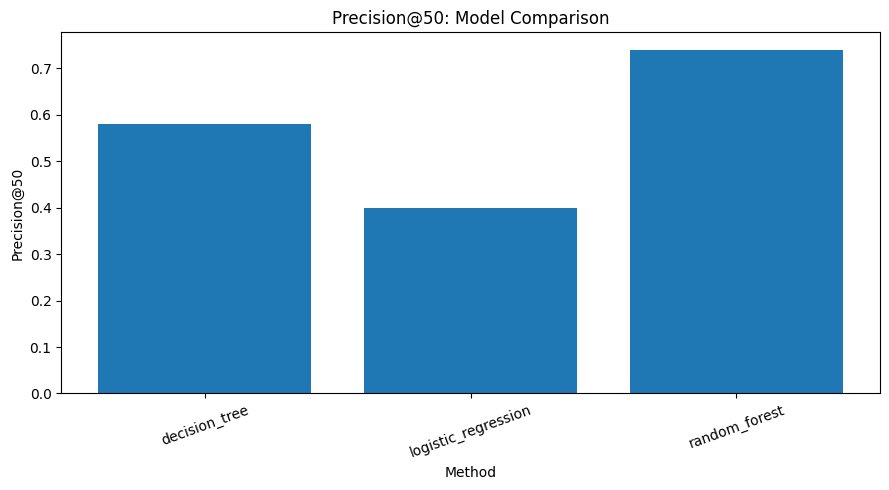

✓ Saved: /content/flyrank-ml-internship-starter/outputs/precision_at_50_comparison.png


In [17]:
# ============================================================
# CHART 1 — PRECISION@50 COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    artifact_results_df["Method"],
    artifact_results_df["Precision@50"]
)

plt.title("Precision@50: Model Comparison")
plt.xlabel("Method")
plt.ylabel("Precision@50")
plt.xticks(rotation=20)
plt.tight_layout()

chart1_path = OUTPUT_DIR / "precision_at_50_comparison.png"

plt.savefig(
    chart1_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", chart1_path)

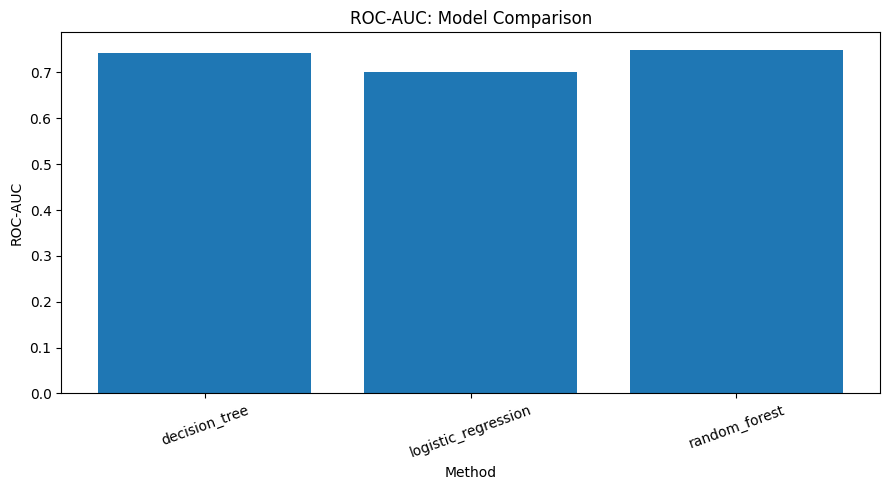

✓ Saved: /content/flyrank-ml-internship-starter/outputs/roc_auc_comparison.png


In [18]:
# ============================================================
# CHART 2 — ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    artifact_results_df["Method"],
    artifact_results_df["ROC-AUC"]
)

plt.title("ROC-AUC: Model Comparison")
plt.xlabel("Method")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)
plt.tight_layout()

chart2_path = OUTPUT_DIR / "roc_auc_comparison.png"

plt.savefig(
    chart2_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", chart2_path)

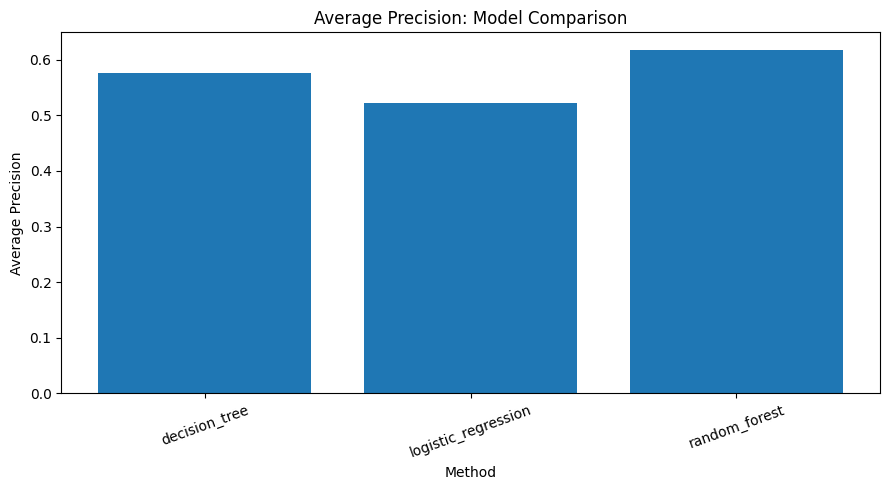

✓ Saved: /content/flyrank-ml-internship-starter/outputs/average_precision_comparison.png


In [19]:
# ============================================================
# CHART 3 — AVERAGE PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    artifact_results_df["Method"],
    artifact_results_df["Average Precision"]
)

plt.title("Average Precision: Model Comparison")
plt.xlabel("Method")
plt.ylabel("Average Precision")
plt.xticks(rotation=20)
plt.tight_layout()

chart3_path = OUTPUT_DIR / "average_precision_comparison.png"

plt.savefig(
    chart3_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", chart3_path)

### Embedded results artifacts

The main artifacts for the research paper are:

1. **Model comparison table** — compares the transparent baseline, Logistic Regression, Decision Tree, and Random Forest using Precision@20, Precision@50, Precision@100, ROC-AUC, and Average Precision.

2. **Precision@50 comparison chart** — shows the primary model-selection metric used by the evaluation procedure.

3. **ROC-AUC comparison chart** — shows the overall ranking/discrimination measurement for the baseline and ML models.

4. **Average Precision comparison chart** — provides an additional measure of performance for the declining-content classification task.

The artifacts are generated directly from the measured model evaluation results rather than manually entered values.

In [20]:
# ============================================================
# ARTIFACT MANIFEST
# ============================================================

artifact_manifest = pd.DataFrame({
    "Artifact": [
        "Results comparison table",
        "Precision@50 comparison",
        "ROC-AUC comparison",
        "Average Precision comparison"
    ],
    "File": [
        "paper_results_table.csv",
        "precision_at_50_comparison.png",
        "roc_auc_comparison.png",
        "average_precision_comparison.png"
    ],
    "Purpose": [
        "Model vs baseline metrics",
        "Primary model-selection metric",
        "Overall discrimination comparison",
        "Additional ranking-quality comparison"
    ]
})

display(artifact_manifest)

manifest_path = OUTPUT_DIR / "paper_artifact_manifest.csv"

artifact_manifest.to_csv(
    manifest_path,
    index=False
)

print("\n✓ Artifact manifest saved:", manifest_path)
print("\n✓ SECTION 7 ARTIFACTS COMPLETE")

,Artifact,File,Purpose
0,Results comparison table,paper_results_table.csv,Model vs baseline metrics
1,Precision@50 comparison,precision_at_50_comparison.png,Primary model-selection metric
2,ROC-AUC comparison,roc_auc_comparison.png,Overall discrimination comparison
3,Average Precision comparison,average_precision_comparison.png,Additional ranking-quality comparison



✓ Artifact manifest saved: /content/flyrank-ml-internship-starter/outputs/paper_artifact_manifest.csv

✓ SECTION 7 ARTIFACTS COMPLETE


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
